In [13]:
import cupy as cp
from cuml.svm import SVR
from cuml.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, brier_score_loss
from time import time
from tabulate import tabulate
from sklearn.base import BaseEstimator, ClassifierMixin
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Parameters
RANDOM_STATE = 42
TEST_SIZE = 0.1

In [3]:
import numpy as np
import pandas as pd
import cupy as cp
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import brier_score_loss

# Load data
df = pd.read_csv("../datasets/basic_all_dataset.csv")

# Normalize features
scaler = MinMaxScaler()
columns = ["RED.totalGoldRatio",
    "BLUE.totalGoldRatio",
    "RED.levelRatio",
    "BLUE.levelRatio",
    "RED.TOWER_BUILDING.kills",
    "BLUE.TOWER_BUILDING.kills",
    "RED.INHIBITOR_BUILDING.kills",
    "BLUE.INHIBITOR_BUILDING.kills",
    "RED.OBJECTIF.kills",
    "BLUE.OBJECTIF.kills"]

df[columns] = scaler.fit_transform(df[columns].values)

# Define timestamp bins (60000 step)
df["time_bin"] = (df["timestamp"] // 60000) * 60000

# Compute percentage of total dataset for each bin
bin_counts = df["time_bin"].value_counts(normalize=True) * 100

print("Percentage of dataset for each time bin:")
for time_bin, percentage in bin_counts.items():
    print(f"Time Bin {int(time_bin)} - {percentage:.2f}% of dataset")
print("Min timestamp:", df["timestamp"].min())
print("Max timestamp:", df["timestamp"].max())
print("Unique time bins:", df["time_bin"].unique())

Percentage of dataset for each time bin:
Time Bin 900000 - 3.72% of dataset
Time Bin 120000 - 3.50% of dataset
Time Bin 60000 - 3.50% of dataset
Time Bin 0 - 3.50% of dataset
Time Bin 300000 - 3.50% of dataset
Time Bin 180000 - 3.50% of dataset
Time Bin 240000 - 3.50% of dataset
Time Bin 360000 - 3.50% of dataset
Time Bin 480000 - 3.50% of dataset
Time Bin 420000 - 3.50% of dataset
Time Bin 540000 - 3.50% of dataset
Time Bin 600000 - 3.50% of dataset
Time Bin 720000 - 3.50% of dataset
Time Bin 660000 - 3.50% of dataset
Time Bin 780000 - 3.50% of dataset
Time Bin 840000 - 3.50% of dataset
Time Bin 960000 - 3.34% of dataset
Time Bin 1080000 - 3.28% of dataset
Time Bin 1020000 - 3.25% of dataset
Time Bin 1140000 - 3.21% of dataset
Time Bin 1200000 - 3.10% of dataset
Time Bin 1260000 - 3.00% of dataset
Time Bin 1320000 - 2.94% of dataset
Time Bin 1380000 - 2.83% of dataset
Time Bin 1440000 - 2.67% of dataset
Time Bin 1500000 - 2.48% of dataset
Time Bin 1560000 - 2.35% of dataset
Time Bin 1

In [4]:
df.describe()

,timestamp,RED.totalGoldRatio,BLUE.totalGoldRatio,RED.levelRatio,BLUE.levelRatio,RED.TOWER_BUILDING.kills,BLUE.TOWER_BUILDING.kills,RED.INHIBITOR_BUILDING.kills,BLUE.INHIBITOR_BUILDING.kills,RED.OBJECTIF.kills,BLUE.OBJECTIF.kills,winner,time_bin
count,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06,6.587262e+06
mean,8.660074e+05,5.145901e-01,4.854099e-01,5.005353e-01,4.994647e-01,9.865924e-02,9.237129e-02,8.045283e-03,7.131725e-03,1.662025e-01,2.121925e-01,4.904863e-01,8.647139e+05
std,5.586214e+05,8.654116e-02,8.654116e-02,6.014079e-02,6.014079e-02,1.437330e-01,1.384941e-01,3.511997e-02,3.298510e-02,1.686580e-01,1.945899e-01,4.999095e-01,5.571171e+05
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.201310e+05,4.601678e-01,4.298057e-01,4.641509e-01,4.627451e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.200000e+05
50%,8.402750e+05,5.102536e-01,4.897464e-01,5.000000e-01,5.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.176471e-01,1.875000e-01,0.000000e+00,8.400000e+05
75%,1.260468e+06,5.701943e-01,5.398322e-01,5.372549e-01,5.358491e-01,1.764706e-01,1.764706e-01,0.000000e+00,0.000000e+00,2.941176e-01,3.750000e-01,1.000000e+00,1.260000e+06
max,3.903826e+06,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.900000e+06


In [5]:
#activation_functions = {
#    "none": lambda x: x,
#    "sigmoid": lambda x: 1 / (1 + np.exp(-x)),
#    "relu": lambda x: np.maximum(0, x),
#    "leaky_relu": lambda x, alpha=0.01: np.where(x > 0, x, alpha * x),
#    "elu": lambda x, alpha=1.0: np.where(x > 0, x, alpha * (np.exp(x) - 1)),
#    "tanh": lambda x: np.tanh(x),
#    "softplus": lambda x: np.log(1 + np.exp(x)),
#    "swish": lambda x: x / (1 + np.exp(-x)),
#    "hard_sigmoid": lambda x: np.clip((x + 1) / 2, 0, 1),
#    "gaussian": lambda x, mean=0, sigma=1: np.exp(-0.5 * ((x - mean) / sigma) ** 2),
#}
#
#kernels = ["linear", "poly", "rbf", "sigmoid"]
#
#all_results = {kernel: {activation: {'brier': [], 'accuracy': []} for activation in activation_functions.keys()} for kernel in kernels}
#
#svm_models = []
#
#for time_bin, df_bin in df.groupby("time_bin"):
#    print(f"start bin {time_bin}")
#    start = time()
#
#    X_bin_gpu = cp.asarray(df_bin.drop(columns=["timestamp", "winner", "time_bin"]))
#    y_bin_gpu = cp.asarray(df_bin["winner"])
#
#    for kernel in kernels:
#        svm_model = SVR(kernel=kernel, max_iter=1000, verbose=True)
#        svm_model.fit(X_bin_gpu, y_bin_gpu)
#
#        pred_gpu = svm_model.predict(X_bin_gpu).get()
#
#        for activation_name, activation_fn in activation_functions.items():
#            pred_activated = activation_fn(pred_gpu)
#
#            pred_activated = np.clip(pred_activated, 0, 1)
#
#            brier = brier_score_loss(y_bin_gpu.get(), pred_activated)
#
#            accuracy = accuracy_score(y_bin_gpu.get(), np.round(pred_activated))
#
#            all_results[kernel][activation_name]['brier'].append(brier)
#            all_results[kernel][activation_name]['accuracy'].append(accuracy)
#
#
#        svm_models.append((time_bin, kernel, svm_model))
#
#    print(f"Time: {time() - start:.2f} sec")
#
#mean_results = []
#for kernel, activation_metrics in all_results.items():
#    for activation_name, metrics in activation_metrics.items():
#        mean_brier = np.mean(metrics['brier'])
#        mean_accuracy = np.mean(metrics['accuracy'])
#        mean_results.append([kernel, activation_name, f"{mean_brier:.4f}", f"{mean_accuracy:.4f}"])
#
#headers = ['Kernel', 'Activation', 'Brier Score', 'Accuracy']
#print(tabulate(mean_results, headers=headers, tablefmt='grid'))

print("""
+----------+--------------+---------------+------------+
| Kernel   | Activation   |   Brier Score |   Accuracy |
+==========+==============+===============+============+
| linear   | none         |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | sigmoid      |        0.2715 |     0.5772 |
+----------+--------------+---------------+------------+
| linear   | relu         |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | leaky_relu   |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | elu          |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | tanh         |        0.2832 |     0.6488 |
+----------+--------------+---------------+------------+
| linear   | softplus     |        0.3577 |     0.559  |
+----------+--------------+---------------+------------+
| linear   | swish        |        0.3028 |     0.6277 |
+----------+--------------+---------------+------------+
| linear   | hard_sigmoid |        0.3025 |     0.5772 |
+----------+--------------+---------------+------------+
| linear   | gaussian     |        0.3851 |     0.5654 |
+----------+--------------+---------------+------------+
| poly     | none         |        0.2608 |     0.7054 |
+----------+--------------+---------------+------------+
| poly     | sigmoid      |        0.2876 |     0.6059 |
+----------+--------------+---------------+------------+
| poly     | relu         |        0.2608 |     0.7054 |
+----------+--------------+---------------+------------+
| poly     | leaky_relu   |        0.2608 |     0.7054 |
+----------+--------------+---------------+------------+
| poly     | elu          |        0.2608 |     0.7054 |
+----------+--------------+---------------+------------+
| poly     | tanh         |        0.2693 |     0.7055 |
+----------+--------------+---------------+------------+
| poly     | softplus     |        0.3463 |     0.5601 |
+----------+--------------+---------------+------------+
| poly     | swish        |        0.282  |     0.6933 |
+----------+--------------+---------------+------------+
| poly     | hard_sigmoid |        0.2911 |     0.6059 |
+----------+--------------+---------------+------------+
| poly     | gaussian     |        0.4411 |     0.5551 |
+----------+--------------+---------------+------------+
| rbf      | none         |        0.2583 |     0.6908 |
+----------+--------------+---------------+------------+
| rbf      | sigmoid      |        0.275  |     0.5904 |
+----------+--------------+---------------+------------+
| rbf      | relu         |        0.2583 |     0.6908 |
+----------+--------------+---------------+------------+
| rbf      | leaky_relu   |        0.2583 |     0.6908 |
+----------+--------------+---------------+------------+
| rbf      | elu          |        0.2583 |     0.6908 |
+----------+--------------+---------------+------------+
| rbf      | tanh         |        0.2642 |     0.6929 |
+----------+--------------+---------------+------------+
| rbf      | softplus     |        0.352  |     0.5544 |
+----------+--------------+---------------+------------+
| rbf      | swish        |        0.2809 |     0.6831 |
+----------+--------------+---------------+------------+
| rbf      | hard_sigmoid |        0.2903 |     0.5904 |
+----------+--------------+---------------+------------+
| rbf      | gaussian     |        0.4199 |     0.564  |
+----------+--------------+---------------+------------+
| sigmoid  | none         |        0.3729 |     0.5736 |
+----------+--------------+---------------+------------+
| sigmoid  | sigmoid      |        0.3234 |     0.5673 |
+----------+--------------+---------------+------------+
| sigmoid  | relu         |        0.3729 |     0.5736 |
+----------+--------------+---------------+------------+
| sigmoid  | leaky_relu   |        0.3729 |     0.5736 |
+----------+--------------+---------------+------------+
| sigmoid  | elu          |        0.3729 |     0.5736 |
+----------+--------------+---------------+------------+
| sigmoid  | tanh         |        0.3433 |     0.575  |
+----------+--------------+---------------+------------+
| sigmoid  | softplus     |        0.4063 |     0.5663 |
+----------+--------------+---------------+------------+
| sigmoid  | swish        |        0.3471 |     0.5731 |
+----------+--------------+---------------+------------+
| sigmoid  | hard_sigmoid |        0.382  |     0.5673 |
+----------+--------------+---------------+------------+
| sigmoid  | gaussian     |        0.3598 |     0.5582 |
+----------+--------------+---------------+------------+
""")


+----------+--------------+---------------+------------+
| Kernel   | Activation   |   Brier Score |   Accuracy |
+==========+==============+===============+============+
| linear   | none         |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | sigmoid      |        0.2715 |     0.5772 |
+----------+--------------+---------------+------------+
| linear   | relu         |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | leaky_relu   |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | elu          |        0.2852 |     0.6549 |
+----------+--------------+---------------+------------+
| linear   | tanh         |        0.2832 |     0.6488 |
+----------+--------------+---------------+------------+
| linear   | softplus     |        0.3577 |     0.559  |
+----------+--------------+---------------+------------+
| linear   | swish        |   

In [6]:
all_brier = []
all_accuracy = []
svm_models = []
for time_bin, df_bin in df.groupby("time_bin"):
    print(f"start bin {time_bin}")
    start = time()

    X_bin_gpu = cp.asarray(df_bin.drop(columns=["timestamp", "winner", "time_bin"]))
    y_bin_gpu = cp.asarray(df_bin["winner"])

    svm_model = SVR(
        C=0.0001,            # Higher C for better fit, but increases risk of overfitting
        kernel='poly',       # Polynomial kernel
        degree=3,            # Keep it at 3 unless you need more complexity
        gamma='scale',       # ‘scale’ is usually a good choice; manually set if needed
        coef0=1.0,           # Helps adjust the influence of higher-degree terms
        tol=1e-4,            # Lower tolerance for better convergence
        max_iter=15000,      # Increase if necessary
        cache_size=2048.0,   # Increase cache size to reduce training time
        nochange_steps=5000, # Give more room for convergence
        verbose=True         # Enable debugging, verbose=True)
    )
    svm_model.fit(X_bin_gpu, y_bin_gpu)

    pred_gpu = svm_model.predict(X_bin_gpu).get()
    pred_activated = np.clip(pred_gpu, 0, 1)
    brier = brier_score_loss(y_bin_gpu.get(), pred_activated)
    accuracy = accuracy_score(y_bin_gpu.get(), np.round(pred_activated))
    print(f"brier : {brier}, accuracy : {accuracy}")
    
    all_brier.append(brier)
    all_accuracy.append(accuracy)
   
    
    print(f"Time: {time() - start:.2f} sec")

    svm_models.append((time_bin, svm_model))

start bin 0
[2025-03-23 13:45:57.598] [CUML] [debug] Creating working set with 1024 elements
[2025-03-23 13:46:45.002] [CUML] [debug] SMO solver finished after 437 outer iterations, total inner 111787 iterations, and diff 0.000000
brier : 0.39761431704504374, accuracy : 0.5154821036936866
Time: 89.77 sec
start bin 60000
[2025-03-23 13:47:27.279] [CUML] [debug] Creating working set with 1024 elements
[2025-03-23 13:48:17.348] [CUML] [debug] SMO solver finished after 461 outer iterations, total inner 117911 iterations, and diff 0.000008
brier : 0.38357589905128514, accuracy : 0.5157725014953319
Time: 92.36 sec
start bin 120000
[2025-03-23 13:48:59.644] [CUML] [debug] Creating working set with 1024 elements
[2025-03-23 13:49:51.130] [CUML] [debug] SMO solver finished after 476 outer iterations, total inner 122683 iterations, and diff 0.000099
brier : 0.27911540830401693, accuracy : 0.5325474049192762
Time: 93.25 sec
start bin 180000
[2025-03-23 13:50:32.889] [CUML] [debug] Creating workin

In [7]:
import cudf

class TimestampVotingClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, models, bin_size=60000):
        """
        Initialize with a list of tuples (time_bin, model) and the bin size.
        """
        self.models = models
        self.bin_size = bin_size

    def _get_time_bin(self, timestamp):
        """
        Convert a timestamp to its corresponding time bin.
        """
        return (timestamp // self.bin_size) * self.bin_size

    def predict_proba(self, X):
        predictions = []
        X = cudf.DataFrame.from_pandas(X)
        for _, row in X.to_pandas().iterrows():
            timestamp = row["timestamp"]
            time_bin = self._get_time_bin(timestamp)
            # Find the model corresponding to the time_bin
            model = next((model for bin_model, model in self.models if bin_model == time_bin), None)
            if model:
                row = row.drop("timestamp")
                pred = model.predict(cp.asarray(row.values.reshape(1, -1))).get()
                pred_clamped = np.clip(pred, 0, 1)
                predictions.append(pred_clamped)
        return predictions

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.round(proba)

In [8]:
X = df.drop(columns=["winner", "time_bin"])
y = df["winner"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_voting = TimestampVotingClassifier(models=svm_models)
final_prediction = custom_voting.predict_proba(X_test)
brier = brier_score_loss(y_test, final_prediction)
accuracy = accuracy_score(y_test, np.round(final_prediction))
print(f"Brier Score : {brier:.4f}")
print(f"Accuracy :{accuracy}")

Brier Score (Classification): 0.1930


## Model Evaluation

In [11]:
from tabulate import tabulate

def evaluate_classifier(model, X_test, y_test):
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred)
    
    y_pred_probs = model.predict_proba(X_test)
    brier = brier_score_loss(y_test, y_pred_probs)
    
    return accuracy, precision, recall, f1, auc, brier

SVM_classifier_results = evaluate_classifier(custom_voting, X_test, y_test)


headers = ["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC-ROC", "Brier Score"]
classifier_results = [
    ["SVM Classifier"] + list(SVM_classifier_results),
]


print("Classification Metrics:")
print(tabulate(classifier_results, headers=headers, tablefmt="github"))

Classification Metrics:
| Model          |   Accuracy |   Precision |   Recall |   F1-Score |   AUC-ROC |   Brier Score |
|----------------|------------|-------------|----------|------------|-----------|---------------|
| SVM Classifier |   0.727418 |    0.762143 |  0.64572 |   0.699118 |  0.725884 |      0.193002 |


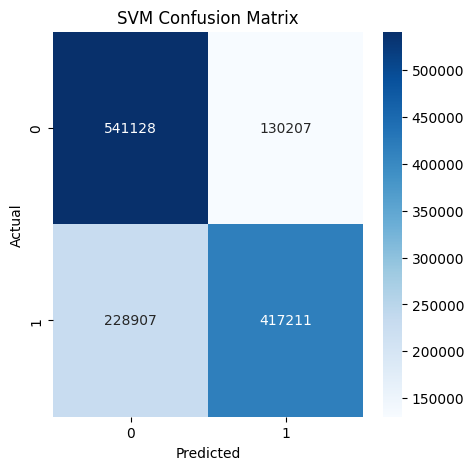

In [14]:
def plot_confusion_matrix(model, X_test, y_test, title):
    cm = confusion_matrix(y_test, model.predict(X_test))
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

plot_confusion_matrix(custom_voting, X_test, y_test, 'SVM Confusion Matrix')

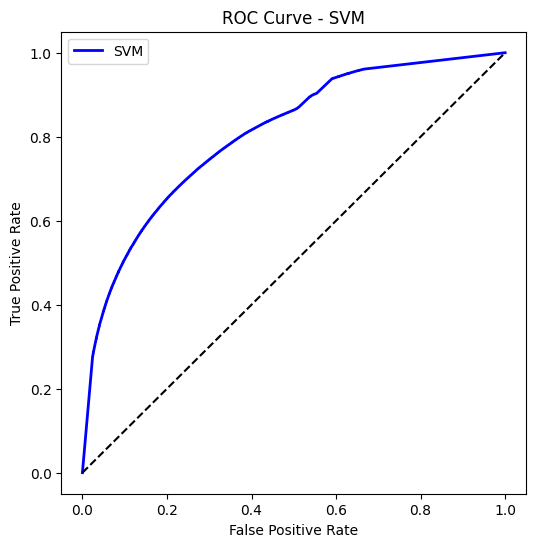

In [17]:
from sklearn.metrics import roc_curve

def plot_roc_curve(model, X_test, y_test, label):
    fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test))

    plt.figure(figsize=(6, 6))
    plt.plot(fpr, tpr, label=label, linewidth=2, color='blue')
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve - {label}')
    plt.legend()
    plt.show()

plot_roc_curve(custom_voting, X_test, y_test, 'SVM')

/home/hgalan/LeagueOfLegendsModelBenchmark/venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:557: RuntimeWarning: Mean of empty slice.
  avg = a.mean(axis, **keepdims_kw)
/home/hgalan/LeagueOfLegendsModelBenchmark/venv/lib/python3.11/site-packages/numpy/_core/_methods.py:138: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


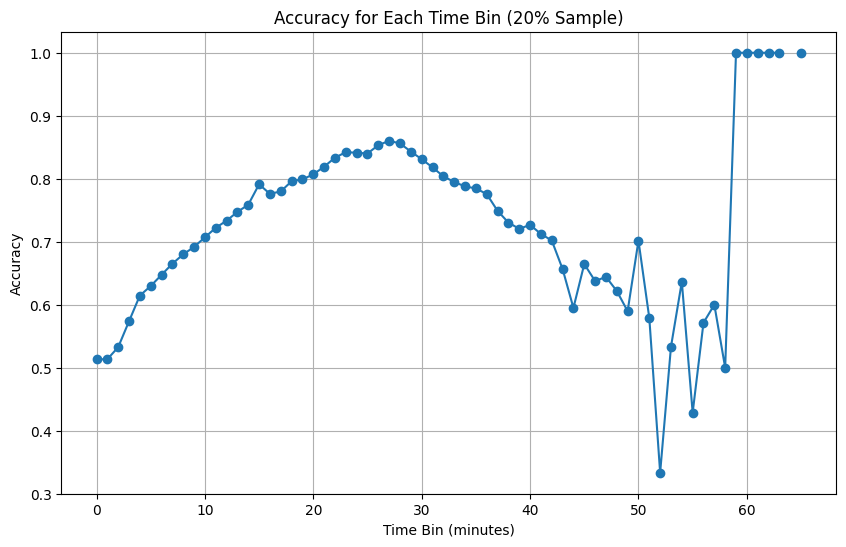

In [20]:
minutes = []
accuracies = []
for time_bin, df_bin in df.groupby("time_bin"):
    minutes.append(time_bin // 60000)
    df_bin_sampled = df_bin.sample(frac=0.2, random_state=42)
    X_test_bin = df_bin_sampled.drop(columns=["winner", "time_bin"])
    y_test_bin = df_bin_sampled["winner"]
    final_prediction = custom_voting.predict_proba(X_test_bin)
    accuracies.append(accuracy_score(y_test_bin, np.round(final_prediction)))

plt.figure(figsize=(10, 6))
plt.plot(minutes, accuracies, marker='o', linestyle='-')
plt.title('Accuracy for Each Time Bin (20% Sample)')
plt.xlabel('Time Bin (minutes)')
plt.ylabel('Accuracy')
plt.grid(True)
plt.show()